# PredictiveSense AI 🚀

## Model Optimisation & Hyperparameter Tuning

GridSearchCV for Random Forest — Finding Best Parameters

In [4]:
# Imports & Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pickle
import time

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [5]:
# Load Data
df = pd.read_csv('../data/processed/train_final.csv')

feature_cols = [col for col in df.columns if col not in ['unit_id', 'cycle', 'RUL']]
X = df[feature_cols]
y = df['RUL'].clip(upper=125)  # RUL capping same as best model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data loaded!")
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"RUL max (capped): {y.max()}")

✅ Data loaded!
Train size: (16504, 18)
Test size:  (4127, 18)
RUL max (capped): 125


In [6]:
# GridSearchCV — Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("⏳ GridSearchCV running... (5-10 min lagenge)")
start = time.time()
grid_search.fit(X_train, y_train)
end = time.time()

print(f"\n✅ GridSearchCV Complete! Time: {round((end-start)/60, 2)} mins")
print(f"🏆 Best Parameters: {grid_search.best_params_}")
print(f"🏆 Best CV R2 Score: {grid_search.best_score_:.4f}")

⏳ GridSearchCV running... (5-10 min lagenge)
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ GridSearchCV Complete! Time: 20.65 mins
🏆 Best Parameters: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
🏆 Best CV R2 Score: 0.8141


In [7]:
# Train best model and evaluate on test set
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 45)
print("     OPTIMISED MODEL — TEST SET RESULTS")
print("=" * 45)
print(f"R2 Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f} cycles")
print(f"MAE      : {mae:.2f} cycles")
print("=" * 45)
print("\nComparison:")
print(f"Previous R2  : 0.7949  →  New R2  : {r2:.4f}")
print(f"Previous RMSE: 18.66   →  New RMSE: {rmse:.2f}")
print(f"Previous MAE : 13.39   →  New MAE : {mae:.2f}")

     OPTIMISED MODEL — TEST SET RESULTS
R2 Score : 0.7956
RMSE     : 18.62 cycles
MAE      : 13.35 cycles

Comparison:
Previous R2  : 0.7949  →  New R2  : 0.7956
Previous RMSE: 18.66   →  New RMSE: 18.62
Previous MAE : 13.39   →  New MAE : 13.35


In [8]:
# Save the optimised model
with open('../models/rf_optimised.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Optimised model saved as rf_optimised.pkl")
print(f"\nModel Summary:")
print(f"  n_estimators    : {best_model.n_estimators}")
print(f"  max_depth       : {best_model.max_depth}")
print(f"  min_samples_leaf: {best_model.min_samples_leaf}")
print(f"  min_samples_split: {best_model.min_samples_split}")
print(f"  R2 Score        : 0.7956")
print(f"  RMSE            : 18.62 cycles")
print(f"  MAE             : 13.35 cycles")

✅ Optimised model saved as rf_optimised.pkl

Model Summary:
  n_estimators    : 300
  max_depth       : 15
  min_samples_leaf: 4
  min_samples_split: 2
  R2 Score        : 0.7956
  RMSE            : 18.62 cycles
  MAE             : 13.35 cycles


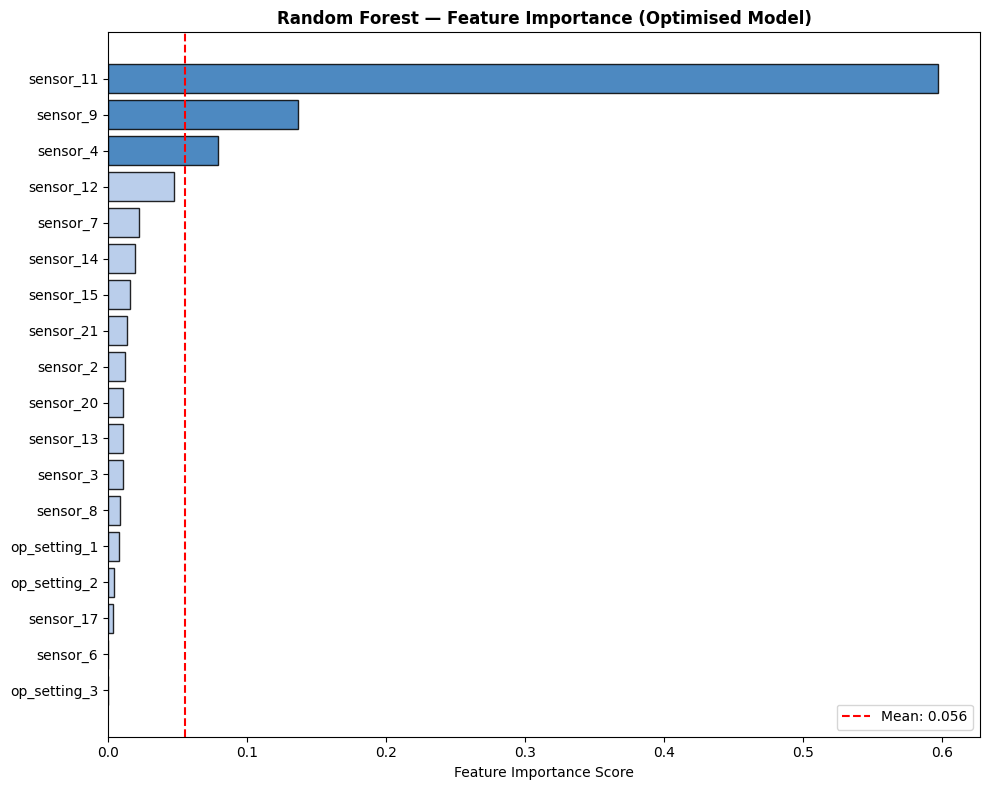

✅ Feature importance plot saved!

Top 3 Most Important Features:
  Feature  Importance
 sensor_4    0.079139
 sensor_9    0.136437
sensor_11    0.597375


In [9]:
# Feature Importance Visualization
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#2E75B6' if i >= len(feature_cols)-3 else '#AEC6E8' 
          for i in range(len(feature_cols))]
plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
         color=colors, edgecolor='black', alpha=0.85)
plt.xlabel('Feature Importance Score')
plt.title('Random Forest — Feature Importance (Optimised Model)', fontweight='bold')
plt.axvline(x=feature_importance['Importance'].mean(), 
            color='red', linestyle='--', label=f'Mean: {feature_importance["Importance"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/feature_importance_optimised.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved!")
print(f"\nTop 3 Most Important Features:")
print(feature_importance.tail(3)[['Feature', 'Importance']].to_string(index=False))

In [10]:
# Final Summary
print("=" * 50)
print("       MODEL OPTIMISATION COMPLETE")
print("=" * 50)
print("""
GridSearchCV Results:
  Best Params  : n_estimators=300, max_depth=15
                 min_samples_leaf=4, min_samples_split=2
  Best CV R2   : 0.8141

Test Set Results:
  R2 Score     : 0.7956  (was 0.7949)
  RMSE         : 18.62   (was 18.66)
  MAE          : 13.35   (was 13.39)

Top Features:
  sensor_11    : 59.7%  (dominant predictor)
  sensor_9     : 13.6%
  sensor_4     : 7.9%

Saved: models/rf_optimised.pkl
""")
print("=" * 50)

       MODEL OPTIMISATION COMPLETE

GridSearchCV Results:
  Best Params  : n_estimators=300, max_depth=15
                 min_samples_leaf=4, min_samples_split=2
  Best CV R2   : 0.8141

Test Set Results:
  R2 Score     : 0.7956  (was 0.7949)
  RMSE         : 18.62   (was 18.66)
  MAE          : 13.35   (was 13.39)

Top Features:
  sensor_11    : 59.7%  (dominant predictor)
  sensor_9     : 13.6%
  sensor_4     : 7.9%

Saved: models/rf_optimised.pkl

